In [12]:


import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, accuracy_score, precision_score, recall_score)
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from imblearn.ensemble import BalancedRandomForestClassifier
from pygam import LogisticGAM, s
from xgboost import XGBClassifier
import warnings

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

csv_path = r"C:\Users\megha\OneDrive - University of Twente\Landslide_ML_CSV.csv"
df = pd.read_csv(csv_path)
print("Columns in the dataset:", df.columns)
df.drop(columns=["wkt_geom"], inplace=True, errors="ignore")

class_0 = df[df["Target_Var"] == 0].sample(n=1746, random_state=42)
class_1 = df[df["Target_Var"] == 1].sample(n=1746, random_state=42)
df_balanced = pd.concat([class_0, class_1]).sample(frac=1, random_state=42).reset_index(drop=True)

X = df_balanced.drop(columns=["Target_Var"]).fillna(0)
y = df_balanced["Target_Var"]

# Split and scale
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, stratify=y, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Feature selection using Random Forest
rf_selector = RandomForestClassifier(n_estimators=100, random_state=42)
rf_selector.fit(X_train_scaled, y_train)
sfm = SelectFromModel(rf_selector, prefit=True, threshold="median")
X_train_selected = sfm.transform(X_train_scaled)
X_test_selected = sfm.transform(X_test_scaled)

# Evaluation function
def evaluate_model(name, model, X_eval, y_true):
    y_pred = model.predict(X_eval)
    print(f"\n================ {name} =================")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall:", recall_score(y_true, y_pred))
    print("AUC ROC:", roc_auc_score(y_true, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))
    print("Classification Report:\n", classification_report(y_true, y_pred))
    
rf_params = {
    'n_estimators': [15,16,17,18,19,20,25,30,35,40,45,50, 75, 100, 125, 150, 155, 160, 165, 170, 175, 180, 185, 190, 195, 200],
    'max_depth': [3,6,8,9,10,11,12,15,18,21,24,25,26,27,28,29,30]
}
rf = GridSearchCV(RandomForestClassifier(random_state=42), rf_params, cv=6, scoring='accuracy', n_jobs=-1)
rf.fit(X_train_selected, y_train)
evaluate_model("Random Forest (Tuned)", rf.best_estimator_, X_test_selected, y_test)

Columns in the dataset: Index(['wkt_geom', 'Aspect1', 'Elevation1', 'NDBI1', 'NDVI1', 'NDWI1', 'TRI1',
       'Slope1', 'PlaCurv1', 'SPI1', 'STI1', 'TPI1', 'WRI1', 'FlowDir1',
       'Rain1', 'Rain2', 'Rain3', 'Rain4', 'Rain5', 'Rain6', 'Rain7', 'Rain8',
       'Rain9', 'Rain10', 'Rain11', 'DisRoad1', 'DisStream1', 'LULC1',
       'Target_Var'],
      dtype='object')

================ Random Forest (Tuned) =================
Accuracy: 0.8387404580152672
Precision: 0.8317757009345794
Recall: 0.8492366412213741
AUC ROC: 0.8387404580152672
Confusion Matrix:
 [[434  90]
 [ 79 445]]
Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.83      0.84       524
           1       0.83      0.85      0.84       524

    accuracy                           0.84      1048
   macro avg       0.84      0.84      0.84      1048
weighted avg       0.84      0.84      0.84      1048



In [14]:
# Retrieve the best hyperparameters and best model
best_params = rf.best_params_
best_model = rf.best_estimator_
print("Best Hyperparameters:", best_params)
print("Best Cross-Validation Score:", rf.best_score_)

Best Hyperparameters: {'max_depth': 24, 'n_estimators': 25}
Best Cross-Validation Score: 0.8580298212651155


In [16]:
rf2 = RandomForestClassifier(random_state=42, n_estimators=3, max_depth=5)

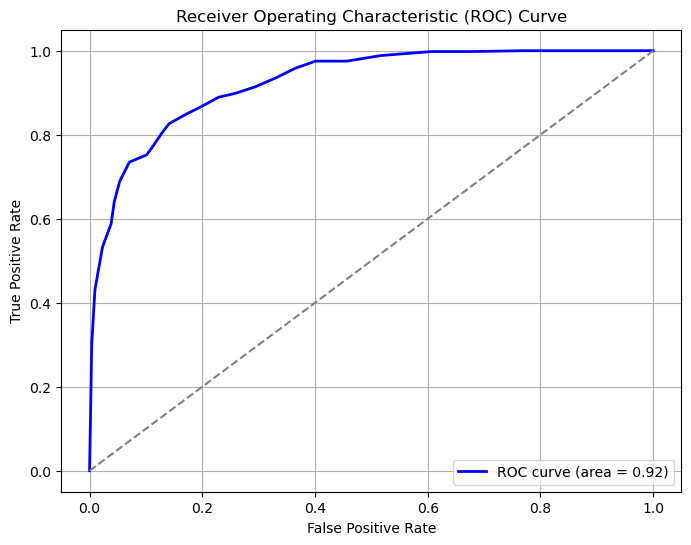

In [18]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# 3. Generate predictions and calculate ROC curve
probs = rf.predict_proba(X_test_selected)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, probs)
roc_auc = auc(fpr, tpr)

# 4. Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid()
plt.show()

In [26]:
import pandas as pd

# Get predicted class labels from the RF model
y_pred_rf = rf.predict(X_test_selected)

# Create DataFrame with results
df_rf = pd.DataFrame({
    'True_Label': y_test,
    'Predicted_Prob': probs,
    'Predicted_Label': y_pred_rf
})

# Save to CSV
save_path = r"C:\Users\megha\OneDrive - University of Twente\Thesis Data\ML Data\Results\RF_Landslide_Results.csv"
df_rf.to_csv(save_path, index=False)
